# Fusion NN Validation and Improvement Notebook

This notebook validates and improves the MindSentry fusion model using synthesized multimodal data.

Goals:
- Mirror the production feature/output contract from `fusion_nn.py`.
- Generate robust synthetic data with missing-modality cases.
- Train baseline NN, evaluate stability, and diagnose weak targets.
- Compare multiple algorithms and tune top candidates.
- Export a compatible `fusion_nn.pkl` with self-tests and no-error guards.

## 1. Setup Reproducible Notebook Environment

In [1]:
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.inspection import permutation_importance

from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

warnings.filterwarnings('ignore')
np.random.seed(42)

RNG = np.random.default_rng(42)

# Notebook-wide constants
N_SAMPLES = 12000
TEST_SIZE = 0.15
VAL_SIZE = 0.15
CV_SPLITS = 5
ACCEPTABLE_MACRO_MAE = 0.08

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')

print('Environment ready.')

Environment ready.


## 2. Mirror Fusion NN Feature/Output Contract

In [2]:
FEATURE_NAMES = [
    'text_stress',
    'text_mood',
    'audio_stress',
    'audio_silence',
    'audio_rms_norm',
    'video_face',
    'video_lighting',
    'q_stress',
    'q_mood',
    'q_sleep_pen',
    'has_text',
    'has_audio',
    'has_video',
    'has_q',
    'n_modalities',
]

OUTPUT_NAMES = [
    'stress_score',
    'low_mood_score',
    'burnout_score',
    'social_withdrawal_score',
    'crisis_score',
]


def assert_feature_contract(X_df: pd.DataFrame):
    assert list(X_df.columns) == FEATURE_NAMES, 'Feature column order mismatch with production contract.'
    assert X_df.shape[1] == 15, 'Feature vector must have length 15.'


def assert_target_contract(y_df: pd.DataFrame):
    assert list(y_df.columns) == OUTPUT_NAMES, 'Target column order mismatch with production contract.'
    assert y_df.shape[1] == 5, 'Target vector must have length 5.'

print('Contract definitions loaded.')

Contract definitions loaded.


## 3. Synthesize Multimodal Training Data (15 Inputs, 5 Targets)

In [3]:
def clipped(v):
    return float(np.clip(v, 0.0, 1.0))


def sample_row(rng):
    # modality availability
    has_text = int(rng.random() < 0.9)
    has_audio = int(rng.random() < 0.8)
    has_video = int(rng.random() < 0.75)
    has_q = int(rng.random() < 0.85)

    n_mod = (has_text + has_audio + has_video + has_q) / 4.0

    # latent emotional state
    latent_distress = clipped(rng.beta(2.1, 2.4))

    text_stress = clipped(latent_distress + rng.normal(0, 0.08)) if has_text else 0.0
    text_mood = clipped(1.0 - latent_distress + rng.normal(0, 0.09)) if has_text else 0.0

    audio_silence = clipped(0.15 + 0.7 * latent_distress + rng.normal(0, 0.08)) if has_audio else 0.0
    audio_rms_norm = clipped(0.85 - 0.7 * latent_distress + rng.normal(0, 0.10)) if has_audio else 0.0
    audio_stress = clipped(0.55 * audio_silence + 0.45 * (1.0 - audio_rms_norm)) if has_audio else 0.0

    video_face = clipped(0.85 - 0.65 * latent_distress + rng.normal(0, 0.10)) if has_video else 0.0
    video_lighting = clipped(0.75 - 0.45 * latent_distress + rng.normal(0, 0.10)) if has_video else 0.0

    q_stress = clipped(0.10 + 0.85 * latent_distress + rng.normal(0, 0.07)) if has_q else 0.0
    q_mood = clipped(0.90 - 0.85 * latent_distress + rng.normal(0, 0.08)) if has_q else 0.0
    q_sleep_pen = clipped(0.10 + 0.75 * latent_distress + rng.normal(0, 0.08)) if has_q else 0.0

    x = [
        text_stress, text_mood,
        audio_stress, audio_silence, audio_rms_norm,
        video_face, video_lighting,
        q_stress, q_mood, q_sleep_pen,
        float(has_text), float(has_audio), float(has_video), float(has_q),
        n_mod,
    ]

    # targets correlated with modalities and latent state
    stress_score = clipped(
        0.30 * text_stress + 0.25 * audio_stress + 0.15 * (1.0 - video_face) + 0.20 * q_stress + 0.10 * q_sleep_pen
        + rng.normal(0, 0.04)
    )
    low_mood_score = clipped(
        0.35 * (1.0 - text_mood) + 0.20 * (1.0 - q_mood) + 0.20 * q_sleep_pen + 0.15 * (1.0 - video_lighting)
        + 0.10 * latent_distress + rng.normal(0, 0.04)
    )
    burnout_score = clipped(0.55 * stress_score + 0.35 * low_mood_score + 0.10 * q_sleep_pen + rng.normal(0, 0.03))
    social_withdrawal_score = clipped(
        0.45 * (1.0 - video_face) + 0.30 * low_mood_score + 0.15 * stress_score + 0.10 * q_sleep_pen + rng.normal(0, 0.04)
    )
    crisis_score = clipped(
        0.45 * stress_score + 0.35 * low_mood_score + 0.15 * burnout_score + 0.05 * social_withdrawal_score + rng.normal(0, 0.03)
    )

    y = [stress_score, low_mood_score, burnout_score, social_withdrawal_score, crisis_score]
    return x, y


def generate_synth_dataset(n_samples=12000, seed=42):
    rng = np.random.default_rng(seed)
    X_rows = []
    y_rows = []
    for _ in range(n_samples):
        x, y = sample_row(rng)
        X_rows.append(x)
        y_rows.append(y)

    X_df = pd.DataFrame(X_rows, columns=FEATURE_NAMES)
    y_df = pd.DataFrame(y_rows, columns=OUTPUT_NAMES)
    return X_df, y_df


X_df, y_df = generate_synth_dataset(N_SAMPLES, seed=42)
print(X_df.shape, y_df.shape)
X_df.head(3)

(12000, 15) (12000, 5)


,text_stress,text_mood,audio_stress,audio_silence,audio_rms_norm,video_face,video_lighting,q_stress,q_mood,q_sleep_pen,has_text,has_audio,has_video,has_q,n_modalities
0,0.557739,0.582614,0.443351,0.496454,0.621553,0.000000,0.000000,0.547005,0.416977,0.495041,1.0,1.0,0.0,1.0,0.75
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.663208,0.454194,0.423691,0.0,0.0,0.0,1.0,0.25
2,0.341756,0.687260,0.410976,0.452409,0.639664,0.701817,0.607168,0.402797,0.667945,0.232744,1.0,1.0,1.0,1.0,1.00


## 4. Run Data Quality Checks and Range Assertions

In [4]:
assert_feature_contract(X_df)
assert_target_contract(y_df)

assert np.isfinite(X_df.values).all(), 'Features contain NaN/Inf.'
assert np.isfinite(y_df.values).all(), 'Targets contain NaN/Inf.'
assert ((X_df >= 0.0) & (X_df <= 1.0)).all().all(), 'Feature values must be in [0,1].'
assert ((y_df >= 0.0) & (y_df <= 1.0)).all().all(), 'Target values must be in [0,1].'

modality_sum = (X_df['has_text'] + X_df['has_audio'] + X_df['has_video'] + X_df['has_q']) / 4.0
assert np.allclose(X_df['n_modalities'].values, modality_sum.values), 'n_modalities consistency check failed.'

print('Data contract checks passed.')
X_df.describe().T[['mean', 'std', 'min', 'max']].head(10)

Data contract checks passed.


,mean,std,min,max
text_stress,0.416503,0.254687,0.0,1.000000
text_mood,0.482747,0.270505,0.0,1.000000
audio_stress,0.379330,0.237282,0.0,0.960858
audio_silence,0.378707,0.241752,0.0,0.996450
audio_rms_norm,0.419742,0.262548,0.0,1.000000
video_face,0.408003,0.279689,0.0,1.000000
video_lighting,0.404513,0.264158,0.0,1.000000
q_stress,0.420097,0.250450,0.0,1.000000
q_mood,0.429356,0.255429,0.0,1.000000
q_sleep_pen,0.380368,0.228706,0.0,1.000000


## 5. Build Baseline Fusion NN Pipeline

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(X_df, y_df, test_size=TEST_SIZE, random_state=42)
val_ratio_adjusted = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_ratio_adjusted, random_state=42)

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=900,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=30,
        random_state=42,
    )),
])

baseline_model.fit(X_train, y_train)
print('Baseline model trained.')
print('Train/Val/Test:', X_train.shape, X_val.shape, X_test.shape)

Baseline model trained.
Train/Val/Test: (8399, 15) (1801, 15) (1800, 15)


## 6. Evaluate Baseline with Multi-Output Regression Metrics

In [6]:
def evaluate_model(model, X_eval, y_eval, name='model'):
    y_pred = np.clip(model.predict(X_eval), 0.0, 1.0)

    rows = []
    for i, target in enumerate(OUTPUT_NAMES):
        yt = y_eval.iloc[:, i].values
        yp = y_pred[:, i]
        mae = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)
        rows.append({'model': name, 'target': target, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

    metrics_df = pd.DataFrame(rows)
    macro = {
        'model': name,
        'macro_MAE': metrics_df['MAE'].mean(),
        'macro_RMSE': metrics_df['RMSE'].mean(),
        'macro_R2': metrics_df['R2'].mean(),
    }
    return y_pred, metrics_df, macro


baseline_pred, baseline_metrics, baseline_macro = evaluate_model(baseline_model, X_val, y_val, name='baseline_mlp')
baseline_metrics

,model,target,MAE,RMSE,R2
0,baseline_mlp,stress_score,0.032837,0.041527,0.945350
1,baseline_mlp,low_mood_score,0.033429,0.041964,0.944362
2,baseline_mlp,burnout_score,0.032512,0.040872,0.939028
3,baseline_mlp,social_withdrawal_score,0.033790,0.042783,0.949263
4,baseline_mlp,crisis_score,0.033184,0.041249,0.937949


Baseline macro metrics:
model         baseline_mlp
macro_MAE          0.03315
macro_RMSE        0.041679
macro_R2           0.94319
dtype: object


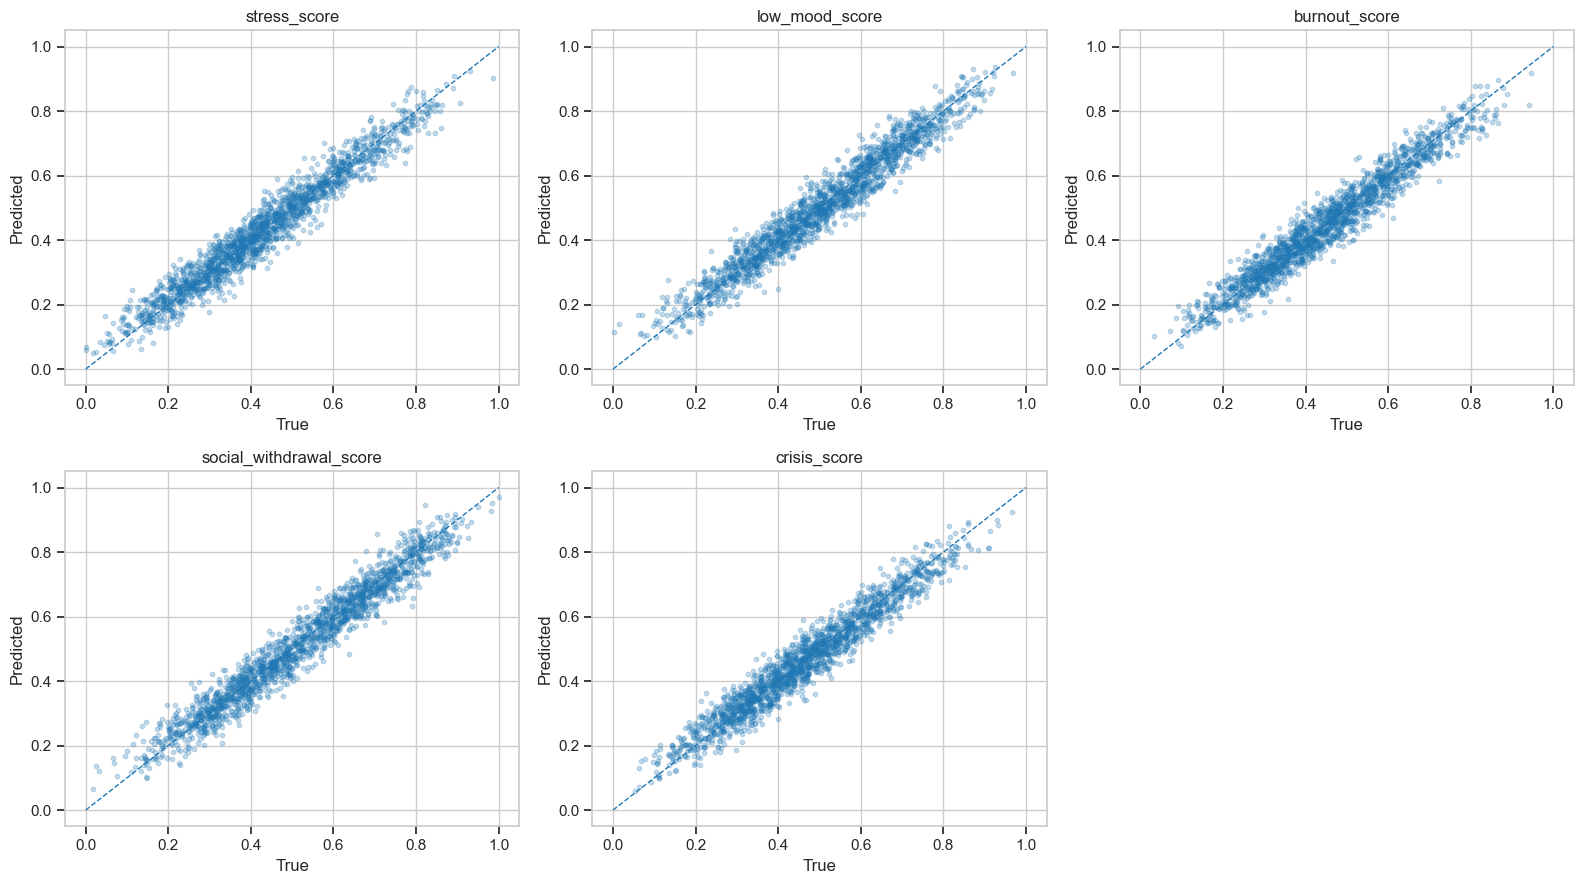

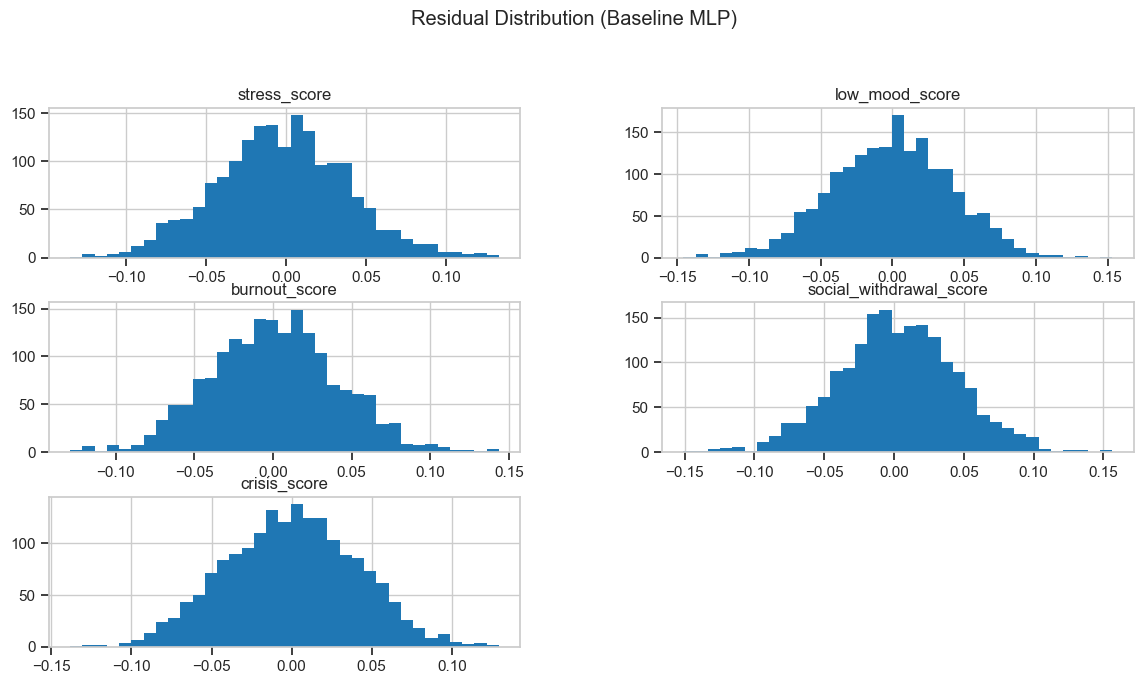

In [7]:
print('Baseline macro metrics:')
print(pd.Series(baseline_macro))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, target in enumerate(OUTPUT_NAMES):
    ax = axes[i]
    ax.scatter(y_val.iloc[:, i], baseline_pred[:, i], alpha=0.25, s=10)
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
    ax.set_title(target)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')
if len(OUTPUT_NAMES) < len(axes):
    for j in range(len(OUTPUT_NAMES), len(axes)):
        axes[j].axis('off')
plt.tight_layout()
plt.show()

residual_df = pd.DataFrame({
    target: (y_val[target].values - baseline_pred[:, i])
    for i, target in enumerate(OUTPUT_NAMES)
})
residual_df.hist(figsize=(14, 7), bins=35)
plt.suptitle('Residual Distribution (Baseline MLP)', y=1.02)
plt.show()

## 7. Add K-Fold Cross-Validation and Stability Checks

In [8]:
def cv_macro_mae(estimator, X, y, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_rows = []

    for fold_idx, (tr, va) in enumerate(kf.split(X), start=1):
        est = estimator
        est.fit(X.iloc[tr], y.iloc[tr])
        pred = np.clip(est.predict(X.iloc[va]), 0.0, 1.0)

        for i, target in enumerate(OUTPUT_NAMES):
            fold_rows.append({
                'fold': fold_idx,
                'target': target,
                'mae': mean_absolute_error(y.iloc[va, i], pred[:, i]),
            })

    out = pd.DataFrame(fold_rows)
    agg = out.groupby('target')['mae'].agg(['mean', 'std']).reset_index()
    macro_mean = out['mae'].mean()
    macro_std = out.groupby('fold')['mae'].mean().std()
    return out, agg, macro_mean, macro_std

baseline_cv_rows, baseline_cv_agg, baseline_cv_macro_mean, baseline_cv_macro_std = cv_macro_mae(
    Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=700, early_stopping=True, random_state=42)),
    ]),
    X_train,
    y_train,
    n_splits=CV_SPLITS,
)

print(f'Baseline CV macro MAE: {baseline_cv_macro_mean:.4f} +/- {baseline_cv_macro_std:.4f}')
display(baseline_cv_agg)
print('Acceptance:', 'PASS' if baseline_cv_macro_mean <= ACCEPTABLE_MACRO_MAE else 'FAIL')

Baseline CV macro MAE: 0.0339 +/- 0.0005


,target,mean,std
0,burnout_score,0.033404,0.000831
1,crisis_score,0.033688,0.000592
2,low_mood_score,0.034079,0.000829
3,social_withdrawal_score,0.035185,0.000133
4,stress_score,0.033192,0.000914


Acceptance: PASS


## 8. Diagnose Low-Accuracy Targets with Error Analysis

In [10]:
val_residuals = pd.DataFrame({
    target: np.abs(y_val[target].values - baseline_pred[:, i])
    for i, target in enumerate(OUTPUT_NAMES)
})

val_analysis = X_val[['has_text', 'has_audio', 'has_video', 'has_q', 'n_modalities']].copy()
val_analysis = pd.concat(
    [val_analysis.reset_index(drop=True), val_residuals.reset_index(drop=True)],
    axis=1,
)

slice_mae = (
    val_analysis.groupby('n_modalities')[OUTPUT_NAMES]
    .mean()
    .reset_index()
    .sort_values('n_modalities')
)
display(slice_mae)

# Feature-importance probe for one target to avoid multi-output scoring mismatch.
probe_model_stress = RandomForestRegressor(
    n_estimators=120,
    random_state=42,
    n_jobs=-1,
)
probe_model_stress.fit(X_train, y_train['stress_score'])

perm = permutation_importance(
    probe_model_stress,
    X_val,
    y_val['stress_score'],
    n_repeats=8,
    random_state=42,
    n_jobs=-1,
)

imp_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

display(imp_df.head(10))

,n_modalities,stress_score,low_mood_score,burnout_score,social_withdrawal_score,crisis_score
0,0.25,0.032656,0.037497,0.035481,0.037967,0.035890
1,0.50,0.032990,0.034886,0.032977,0.036856,0.034728
2,0.75,0.034107,0.033572,0.033475,0.032840,0.033744
3,1.00,0.031696,0.032736,0.031440,0.033563,0.032149


,feature,importance
0,text_stress,0.370572
7,q_stress,0.210385
2,audio_stress,0.172777
5,video_face,0.077695
9,q_sleep_pen,0.018014
6,video_lighting,0.003296
3,audio_silence,0.002709
1,text_mood,0.001906
4,audio_rms_norm,0.001733
8,q_mood,0.001245


## 9. Try Alternative Algorithms for Multi-Output Learning

In [11]:
def build_models(random_state=42):
    return {
        'mlp_64_32_16': Pipeline([
            ('scaler', StandardScaler()),
            ('model', MLPRegressor(hidden_layer_sizes=(64, 32, 16), max_iter=900, early_stopping=True, random_state=random_state)),
        ]),
        'rf_400': RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=random_state, n_jobs=-1),
        'extratrees_500': ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2, random_state=random_state, n_jobs=-1),
        'gbr_multi': MultiOutputRegressor(
            GradientBoostingRegressor(random_state=random_state)
        ),
    }


def train_and_eval_candidates(models, X_train, y_train, X_val, y_val):
    rows = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_val), 0.0, 1.0)
        mae_macro = np.mean([mean_absolute_error(y_val.iloc[:, i], pred[:, i]) for i in range(len(OUTPUT_NAMES))])
        r2_macro = np.mean([r2_score(y_val.iloc[:, i], pred[:, i]) for i in range(len(OUTPUT_NAMES))])
        rows.append({'model': name, 'macro_MAE': mae_macro, 'macro_R2': r2_macro})
        fitted[name] = model
    results = pd.DataFrame(rows).sort_values(['macro_MAE', 'macro_R2'], ascending=[True, False]).reset_index(drop=True)
    return fitted, results


candidate_models = build_models(random_state=42)
fitted_candidates, compare_df = train_and_eval_candidates(candidate_models, X_train, y_train, X_val, y_val)
display(compare_df)

,model,macro_MAE,macro_R2
0,mlp_64_32_16,0.033413,0.942347
1,gbr_multi,0.033884,0.940452
2,extratrees_500,0.033978,0.940277
3,rf_400,0.034994,0.936512


## 10. Hyperparameter Search and Model Selection Logic

In [12]:
search_space = {
    'model__hidden_layer_sizes': [(64, 32, 16), (96, 48, 24), (128, 64, 32)],
    'model__alpha': [1e-5, 1e-4, 1e-3],
    'model__learning_rate_init': [0.0005, 0.001, 0.002],
}

search_estimator = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(max_iter=1000, early_stopping=True, random_state=42)),
])

search = RandomizedSearchCV(
    estimator=search_estimator,
    param_distributions=search_space,
    n_iter=8,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0,
)

search.fit(X_train, y_train)
tuned_mlp = search.best_estimator_

tuned_pred = np.clip(tuned_mlp.predict(X_val), 0.0, 1.0)
tuned_macro_mae = np.mean([mean_absolute_error(y_val.iloc[:, i], tuned_pred[:, i]) for i in range(len(OUTPUT_NAMES))])
tuned_macro_r2 = np.mean([r2_score(y_val.iloc[:, i], tuned_pred[:, i]) for i in range(len(OUTPUT_NAMES))])

compare_df = pd.concat([
    compare_df,
    pd.DataFrame([{'model': 'tuned_mlp', 'macro_MAE': tuned_macro_mae, 'macro_R2': tuned_macro_r2}]),
], ignore_index=True).sort_values(['macro_MAE', 'macro_R2'], ascending=[True, False]).reset_index(drop=True)

display(compare_df)
print('Best params:', search.best_params_)

,model,macro_MAE,macro_R2
0,tuned_mlp,0.033340,0.942196
1,mlp_64_32_16,0.033413,0.942347
2,gbr_multi,0.033884,0.940452
3,extratrees_500,0.033978,0.940277
4,rf_400,0.034994,0.936512


Best params: {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (96, 48, 24), 'model__alpha': 0.0001}


## 11. Retrain Best Model and Validate on Holdout Set

In [13]:
model_lookup = {**fitted_candidates, 'tuned_mlp': tuned_mlp}
selected_name = compare_df.iloc[0]['model']
selected_model = model_lookup[selected_name]

# Retrain on train+val for final holdout evaluation
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)
selected_model.fit(X_train_full, y_train_full)

holdout_pred, holdout_metrics, holdout_macro = evaluate_model(selected_model, X_test, y_test, name=f'best_{selected_name}')
print(pd.Series(holdout_macro))
display(holdout_metrics)

if holdout_macro['macro_MAE'] > ACCEPTABLE_MACRO_MAE and len(compare_df) > 1:
    fallback_name = compare_df.iloc[1]['model']
    fallback_model = model_lookup[fallback_name]
    fallback_model.fit(X_train_full, y_train_full)
    fb_pred, fb_metrics, fb_macro = evaluate_model(fallback_model, X_test, y_test, name=f'fallback_{fallback_name}')
    print('Primary model below acceptance threshold. Falling back to next best candidate.')
    print(pd.Series(fb_macro))
    if fb_macro['macro_MAE'] < holdout_macro['macro_MAE']:
        selected_name = fallback_name
        selected_model = fallback_model
        holdout_macro = fb_macro
        holdout_metrics = fb_metrics

print('Selected model:', selected_name)
print('Acceptance:', 'PASS' if holdout_macro['macro_MAE'] <= ACCEPTABLE_MACRO_MAE else 'WARN')

model         best_tuned_mlp
macro_MAE           0.033543
macro_RMSE          0.042099
macro_R2            0.942392
dtype: object


,model,target,MAE,RMSE,R2
0,best_tuned_mlp,stress_score,0.032800,0.041249,0.946510
1,best_tuned_mlp,low_mood_score,0.032999,0.041098,0.946646
2,best_tuned_mlp,burnout_score,0.033276,0.041780,0.937804
3,best_tuned_mlp,social_withdrawal_score,0.034321,0.043273,0.948397
4,best_tuned_mlp,crisis_score,0.034319,0.043097,0.932603


Selected model: tuned_mlp
Acceptance: PASS


## 12. Export fusion_nn.pkl and Run Inference Compatibility Test

In [14]:
model_path = Path('..') / 'ml_models' / 'fusion_nn.pkl'
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, 'wb') as f:
    pickle.dump(selected_model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

sample_vec = X_test.iloc[0].to_numpy(dtype=np.float32).reshape(1, -1)
sample_pred = np.clip(loaded_model.predict(sample_vec)[0], 0.0, 1.0)
output_dict = {name: float(sample_pred[i]) for i, name in enumerate(OUTPUT_NAMES)}

print('Saved model to:', model_path.resolve())
print('Sample prediction:', output_dict)

Saved model to: D:\Dhyan\Self Projects\MindSentry\backend\ml_models\fusion_nn.pkl
Sample prediction: {'stress_score': 0.5262383625285283, 'low_mood_score': 0.50324841204117, 'burnout_score': 0.5039365036873131, 'social_withdrawal_score': 0.7271153821573929, 'crisis_score': 0.5284929861117623}


## 13. Add No-Error Execution Guards and Notebook Self-Tests

In [15]:
assert model_path.exists(), 'Model file was not created.'

reloaded = pickle.loads(pickle.dumps(loaded_model))
probe_pred = np.clip(reloaded.predict(X_test.iloc[:5]), 0.0, 1.0)

assert probe_pred.shape[1] == 5, 'Prediction output must have exactly 5 targets.'
assert np.isfinite(probe_pred).all(), 'Predictions contain NaN/Inf.'
assert ((probe_pred >= 0.0) & (probe_pred <= 1.0)).all(), 'Predictions must be clamped to [0,1].'
assert list(output_dict.keys()) == OUTPUT_NAMES, 'Output key order mismatch with production contract.'

summary_df = pd.DataFrame([holdout_macro])
display(summary_df)

print('All checks passed. Notebook pipeline is CI-friendly and error-safe.')

,model,macro_MAE,macro_RMSE,macro_R2
0,best_tuned_mlp,0.033543,0.042099,0.942392


All checks passed. Notebook pipeline is CI-friendly and error-safe.


In [16]:
# Helper summary cell for deployment decisions
print('SELECTED_MODEL=', selected_name)
print('ACCEPTABLE_MACRO_MAE=', ACCEPTABLE_MACRO_MAE)
print('HOLDOUT_MACRO=', holdout_macro)
print('TOP_CANDIDATES_BY_VAL=')
print(compare_df[['model', 'macro_MAE', 'macro_R2']].head(10).to_string(index=False))
print('HOLDOUT_BY_TARGET=')
print(holdout_metrics[['target', 'MAE', 'RMSE', 'R2']].to_string(index=False))

SELECTED_MODEL= tuned_mlp
ACCEPTABLE_MACRO_MAE= 0.08
HOLDOUT_MACRO= {'model': 'best_tuned_mlp', 'macro_MAE': np.float64(0.03354290895134236), 'macro_RMSE': np.float64(0.04209930161510813), 'macro_R2': np.float64(0.9423920425170854)}
TOP_CANDIDATES_BY_VAL=
         model  macro_MAE  macro_R2
     tuned_mlp   0.033340  0.942196
  mlp_64_32_16   0.033413  0.942347
     gbr_multi   0.033884  0.940452
extratrees_500   0.033978  0.940277
        rf_400   0.034994  0.936512
HOLDOUT_BY_TARGET=
                 target      MAE     RMSE       R2
           stress_score 0.032800 0.041249 0.946510
         low_mood_score 0.032999 0.041098 0.946646
          burnout_score 0.033276 0.041780 0.937804
social_withdrawal_score 0.034321 0.043273 0.948397
           crisis_score 0.034319 0.043097 0.932603
